In [31]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/priyanshubhatt29/pharma-1/sample_submission.csv
/kaggle/input/datasets/priyanshubhatt29/pharma-1/train.csv
/kaggle/input/datasets/priyanshubhatt29/pharma-1/test.csv


In [32]:
train_df = pd.read_csv('/kaggle/input/datasets/priyanshubhatt29/pharma-1/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/priyanshubhatt29/pharma-1/test.csv')

In [33]:
train_df.describe()

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,20656.000000,22083.000000,16047.000000,16097.000000,19956.0,19931.0,19936.0,19943.0,19913.0,19921.000000,19935.000000,19928.000000,19861.000000,19982.000000,19970.000000,19930.000000
mean,6.974148,4.898871,34.526454,41.972852,0.0,0.0,0.0,1.0,0.0,2.003062,7.486224,0.592483,0.551886,0.536233,0.497747,0.461917
std,4.319475,0.199663,9.852598,13.035501,0.0,0.0,0.0,0.0,0.0,1.411919,2.653393,0.491385,0.497313,0.498698,0.500007,0.498560
min,0.000000,4.092727,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.763109,26.000000,31.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.424703,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899399,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.477132,1.000000,1.000000,1.000000,0.000000,0.000000
75%,11.000000,5.033830,43.000000,53.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.526152,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
train_df['Paternal gene'] = train_df['Paternal gene'].map({'yes': 1, 'no': 0})

In [36]:
train_df.describe()

,Patient Age,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,20656.000000,0.0,22083.000000,16047.000000,16097.000000,19956.0,19931.0,19936.0,19943.0,19913.0,19921.000000,19935.000000,19928.000000,19861.000000,19982.000000,19970.000000,19930.000000
mean,6.974148,NaN,4.898871,34.526454,41.972852,0.0,0.0,0.0,1.0,0.0,2.003062,7.486224,0.592483,0.551886,0.536233,0.497747,0.461917
std,4.319475,NaN,0.199663,9.852598,13.035501,0.0,0.0,0.0,0.0,0.0,1.411919,2.653393,0.491385,0.497313,0.498698,0.500007,0.498560
min,0.000000,NaN,4.092727,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,NaN,4.763109,26.000000,31.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.424703,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,NaN,4.899399,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.477132,1.000000,1.000000,1.000000,0.000000,0.000000
75%,11.000000,NaN,5.033830,43.000000,53.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.526152,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,NaN,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        train_df.loc[:, col] = le.fit_transform(train_df[col])   

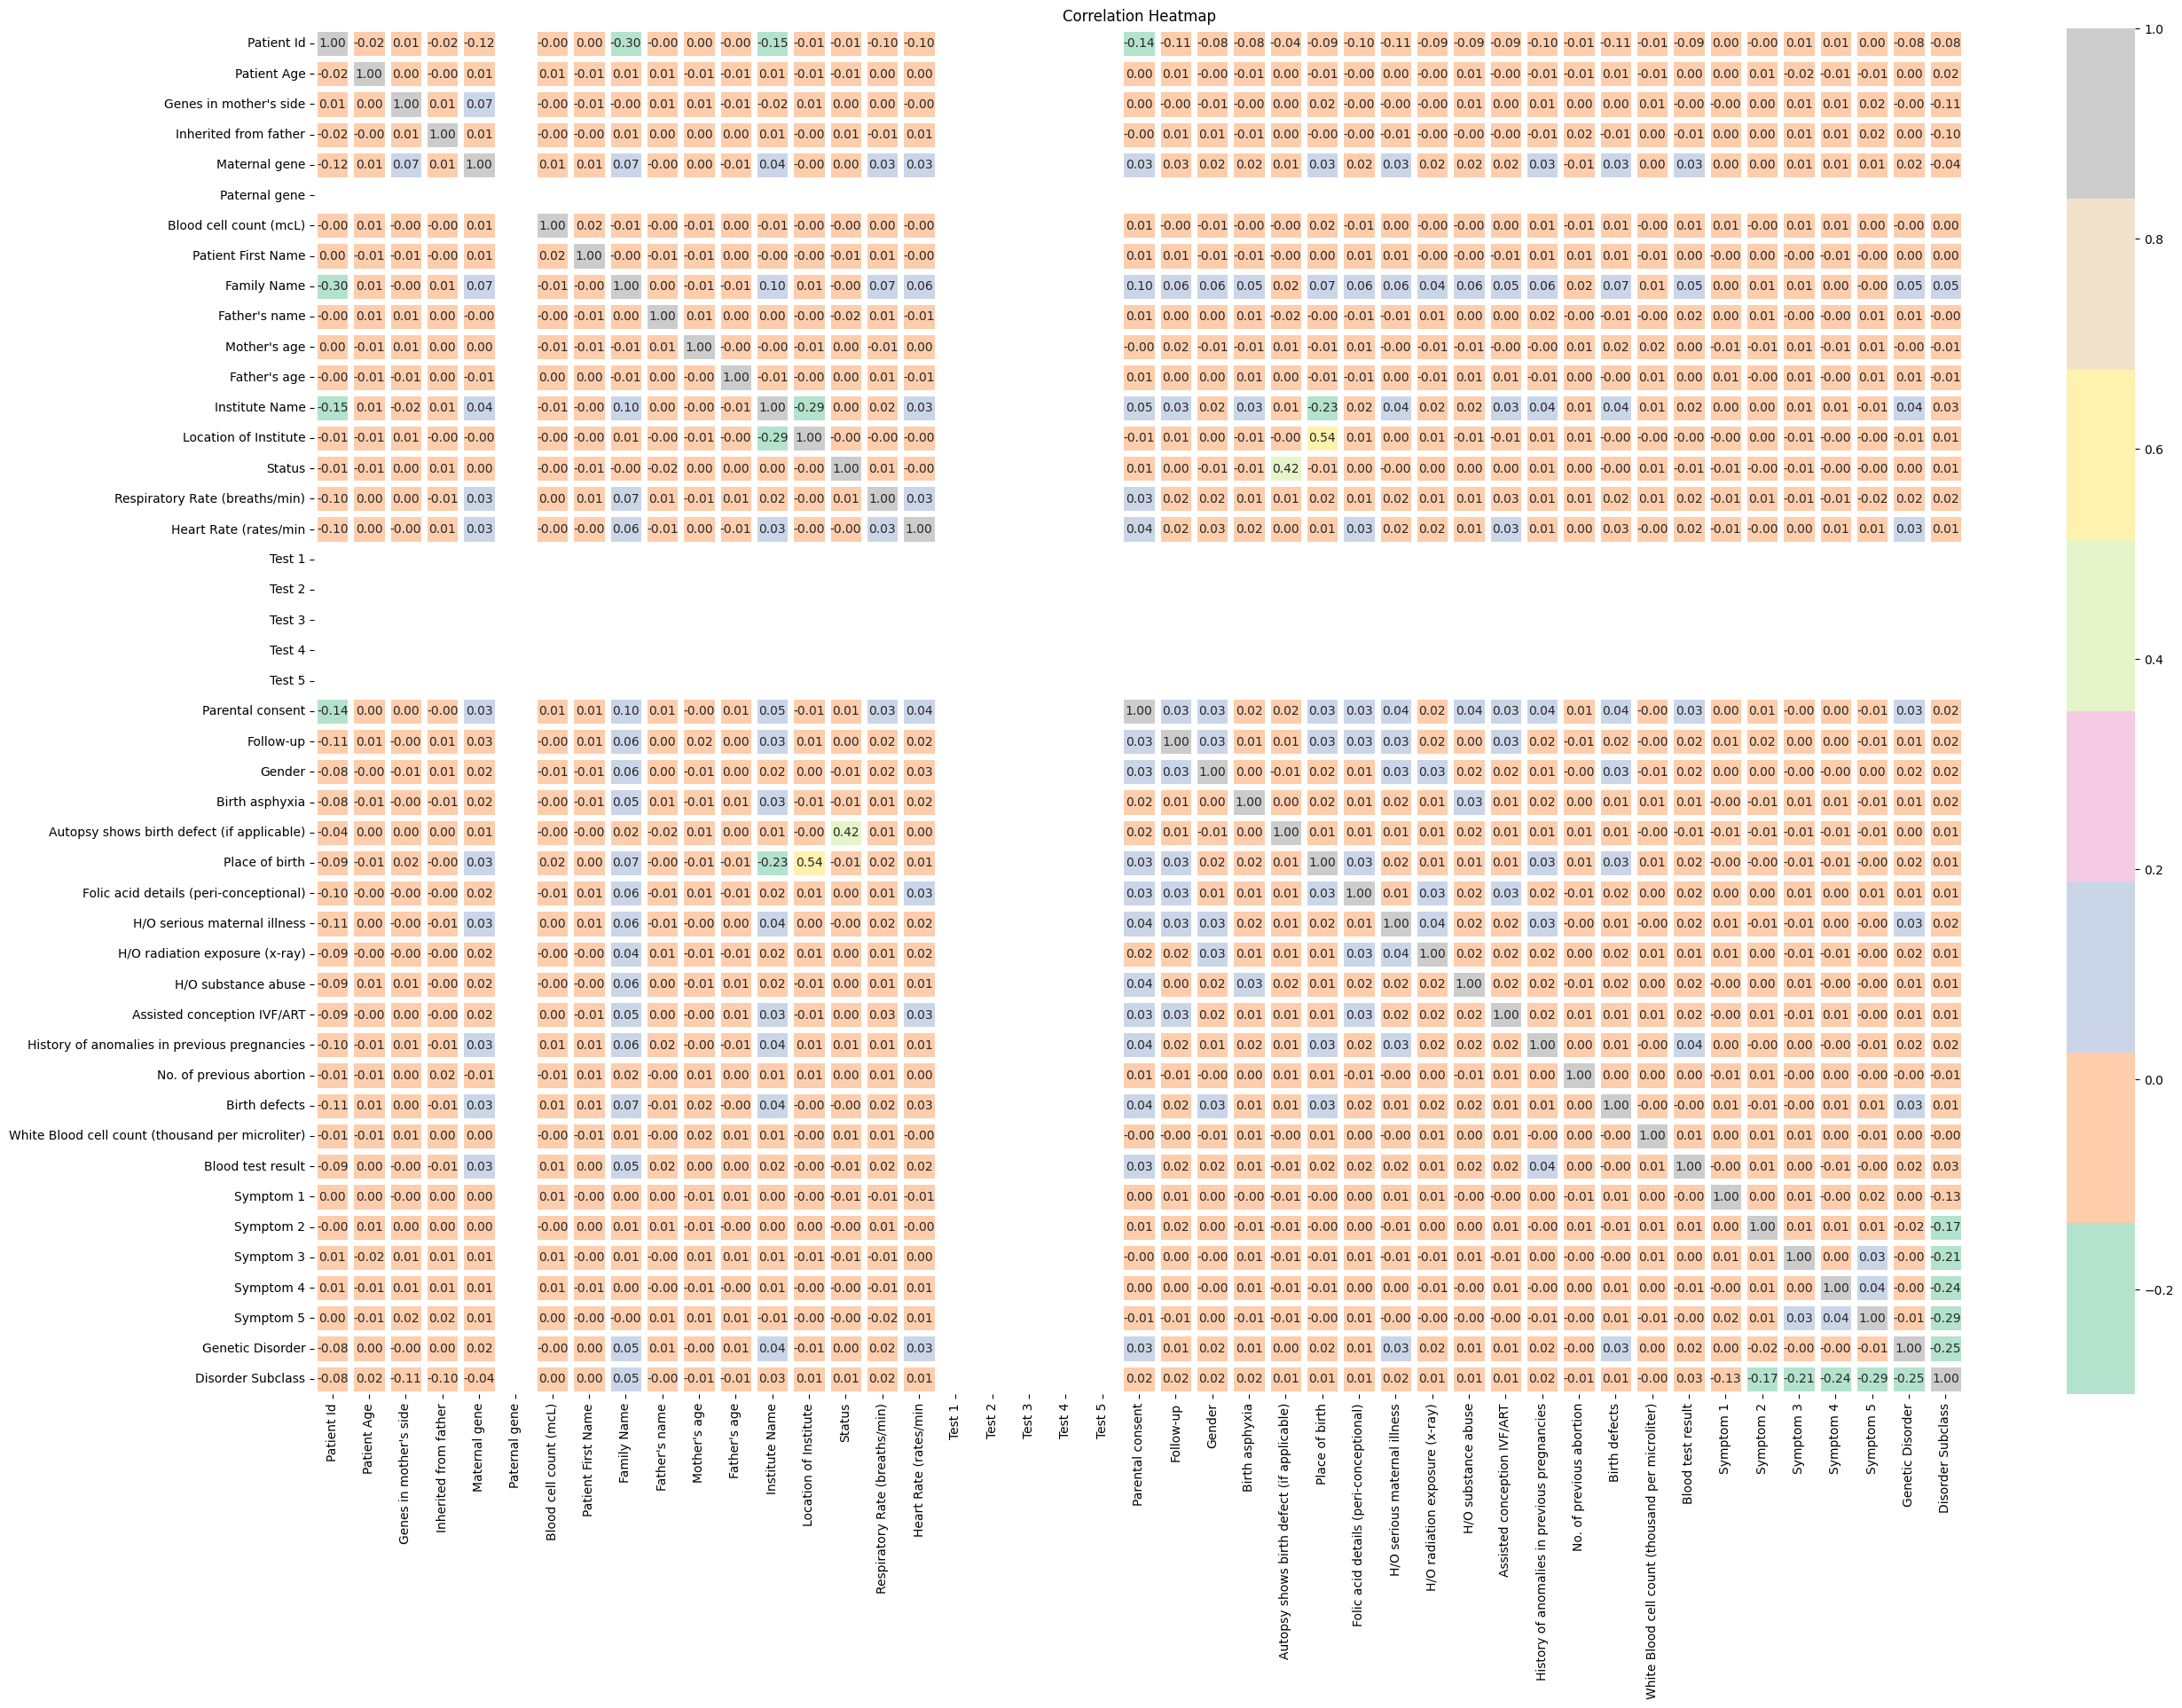

In [39]:
plt.figure(figsize=(30, 20))

sns.heatmap(train_df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=5)

plt.title('Correlation Heatmap')
plt.show()

In [40]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in test_df.columns:
    if test_df[col].dtype == 'object':
        test_df.loc[:, col] = le.fit_transform(test_df[col])   

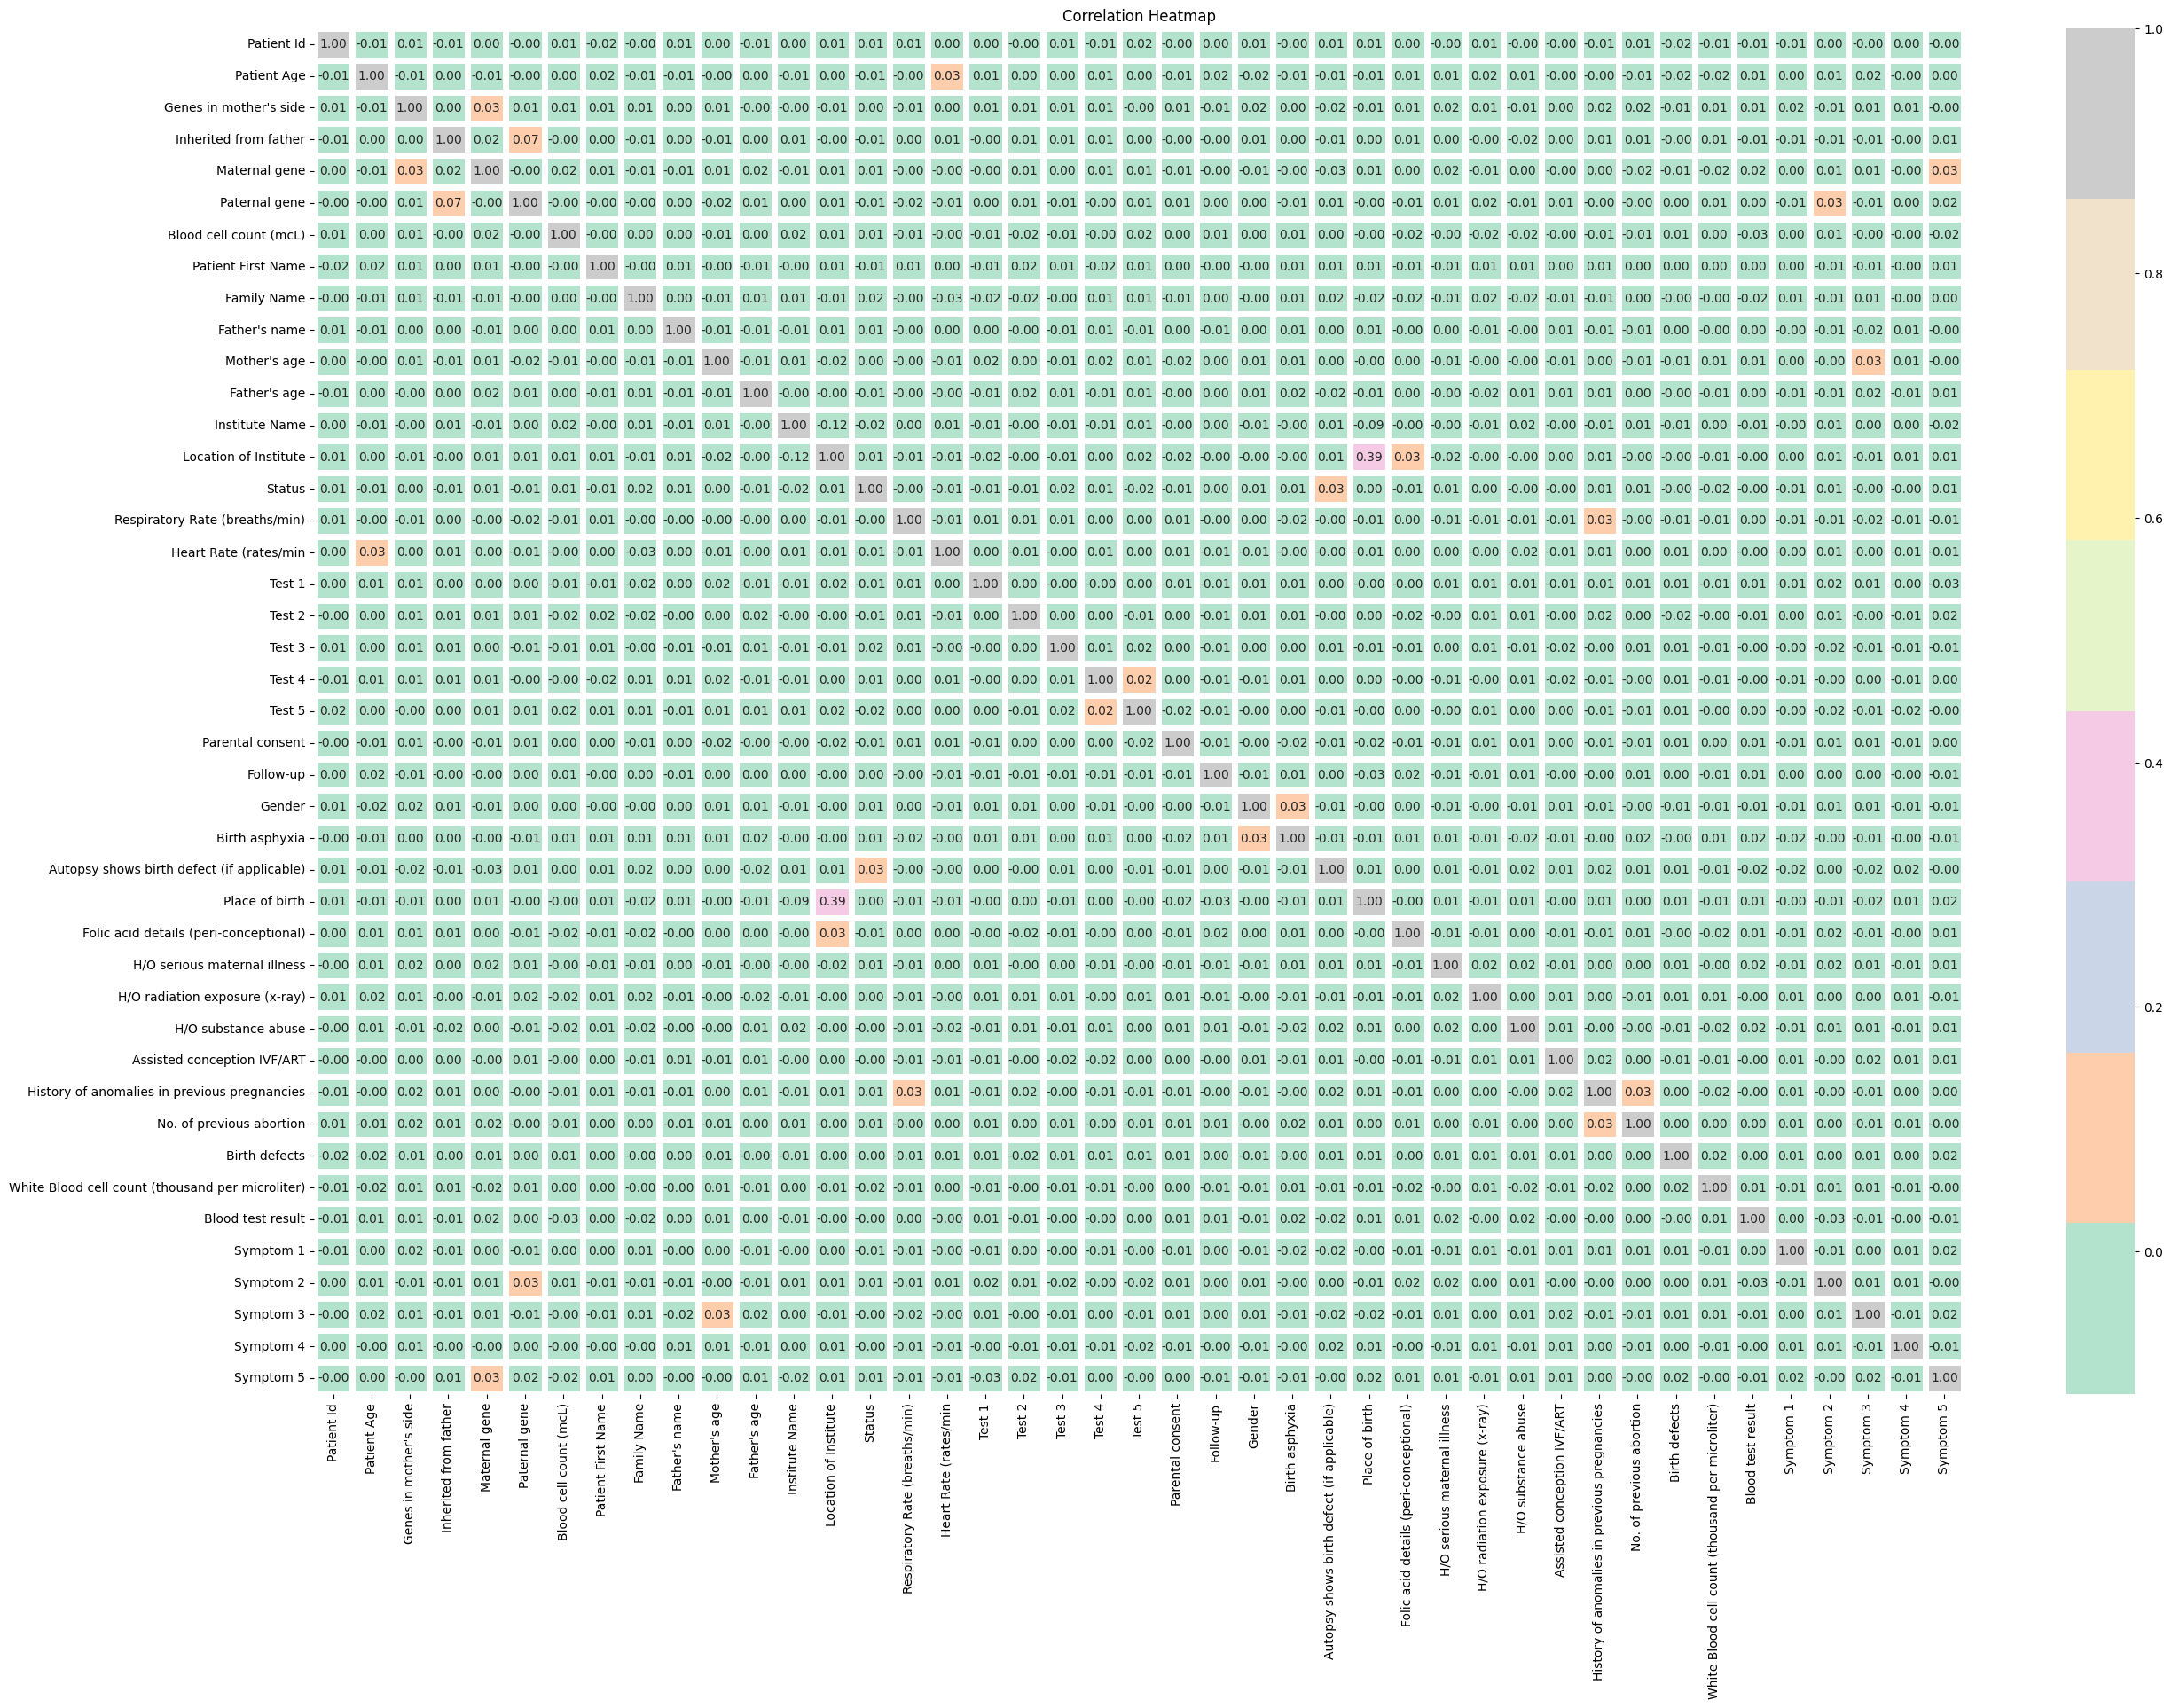

In [41]:
plt.figure(figsize=(30, 20))

sns.heatmap(test_df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=5)

plt.title('Correlation Heatmap')
plt.show()

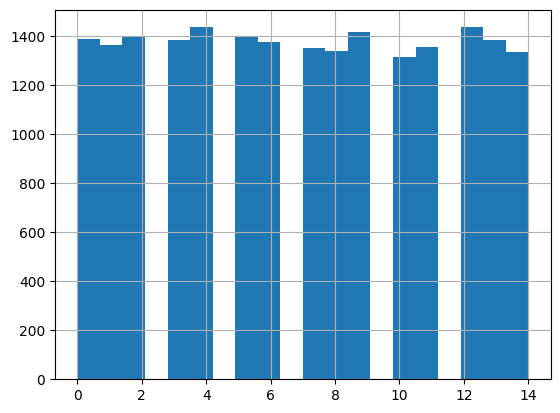

In [43]:
train_df['Patient Age'].hist(bins=20)
plt.show()

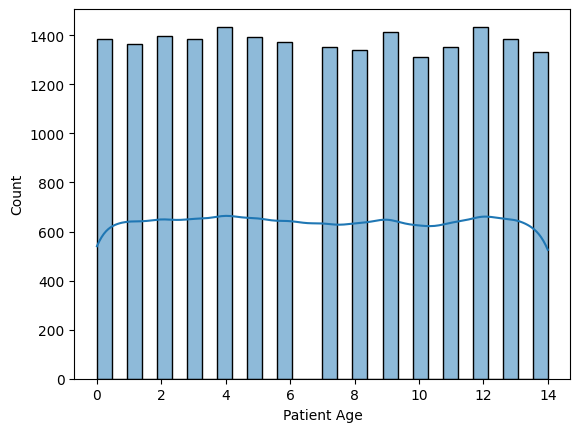

In [44]:
sns.histplot(train_df['Patient Age'], bins=30, kde=True)
plt.show()

PIE CHART****

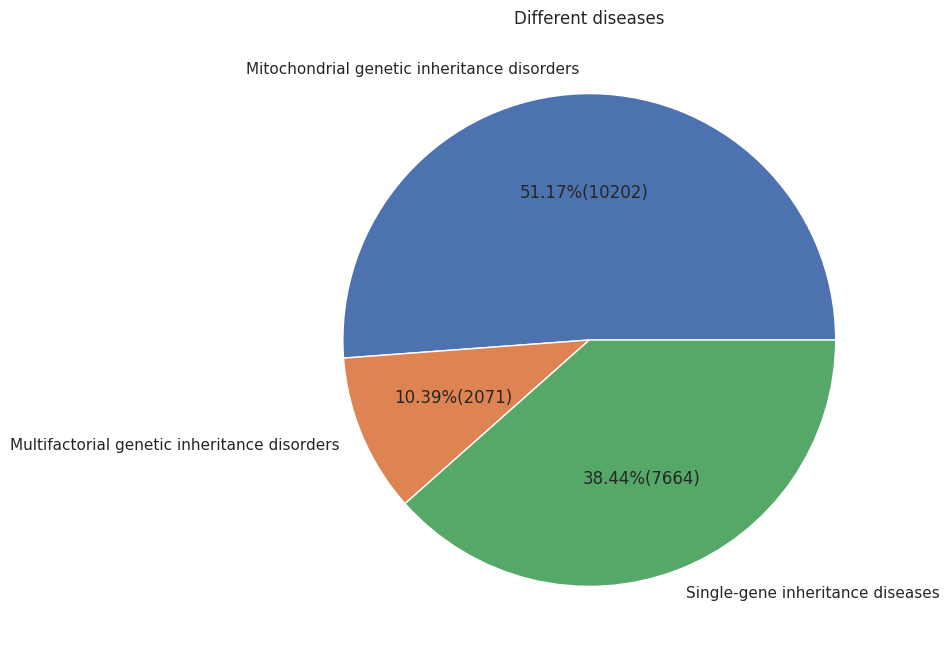

In [52]:
path = r"/kaggle/input/datasets/priyanshubhatt29/pharma-1/train.csv"

train_df = pd.read_csv(path, engine='python', encoding='utf_8_sig')

Gene= train_df.groupby('Genetic Disorder').size()

sns.set()
Gene.plot(kind='pie', title='Different diseases', figsize=[8,8],
          autopct=lambda p: '{:.2f}%({:.0f})'.format(p,(p/100)*Gene.sum()))
plt.show()

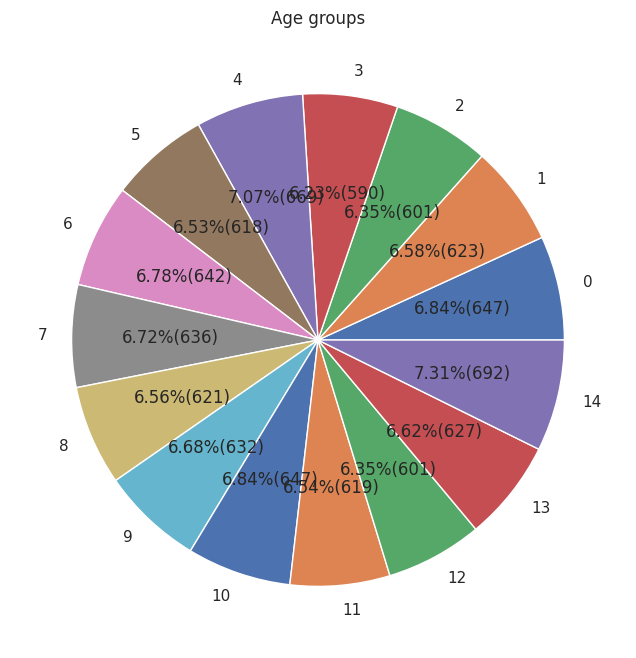

In [55]:
path = r"/kaggle/input/datasets/priyanshubhatt29/pharma-1/test.csv"

test_df = pd.read_csv(path, engine='python', encoding='utf_8_sig')

age= test_df.groupby('Patient Age').size()

sns.set()
age.plot(kind='pie', title='Age groups', figsize=[8,8],
          autopct=lambda p: '{:.2f}%({:.0f})'.format(p,(p/100)*age.sum()))
plt.show()

<Axes: xlabel='Patient Age', ylabel="Father's age">

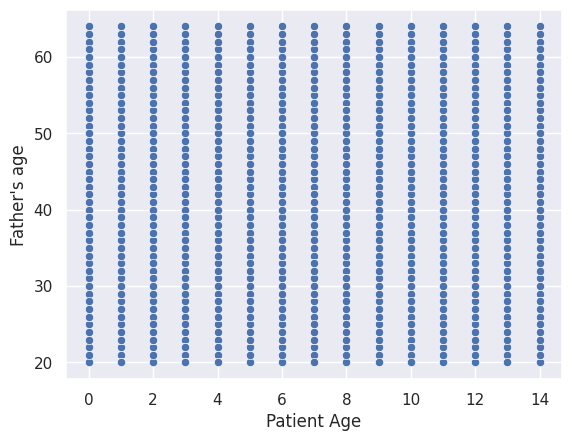

In [66]:
sns.scatterplot(train_df, x=train_df["Patient Age"], y=train_df["Father's age"] )

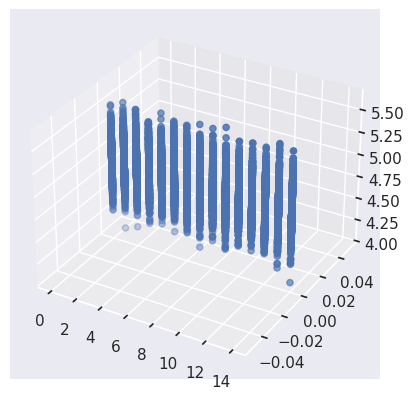

In [69]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter( train_df["Patient Age"], train_df["Test 1"],train_df["Blood cell count (mcL)"])
